# ch253 — Normal Distribution

**Part VIII: Probability** | Computational Mathematics for Programmers

---

## 1. The Gaussian Bell Curve

The normal distribution X ~ N(μ, σ²) is the most important distribution in statistics. Its ubiquity is not coincidence — it is the limiting distribution of sums of independent random variables (Central Limit Theorem, ch254).

PDF:
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- μ: mean (center)
- σ²: variance (spread)
- σ: standard deviation

*(Exponential functions from ch041; integrals for normalization from ch221.)*

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def normal_pdf(x, mu, sigma):
    """Normal PDF — implemented from scratch."""
    coeff = 1 / (sigma * np.sqrt(2 * np.pi))
    exponent = -((x - mu)**2) / (2 * sigma**2)
    return coeff * np.exp(exponent)

x = np.linspace(-5, 5, 500)
pdf_ours  = normal_pdf(x, mu=0, sigma=1)
pdf_scipy = stats.norm.pdf(x, loc=0, scale=1)

print(f"Max deviation from scipy: {np.max(np.abs(pdf_ours - pdf_scipy)):.2e}")
print(f"Numerical integral ≈ 1: {np.trapezoid(pdf_ours, x):.8f}")

Max deviation from scipy: 5.55e-17
Numerical integral ≈ 1: 0.99999943


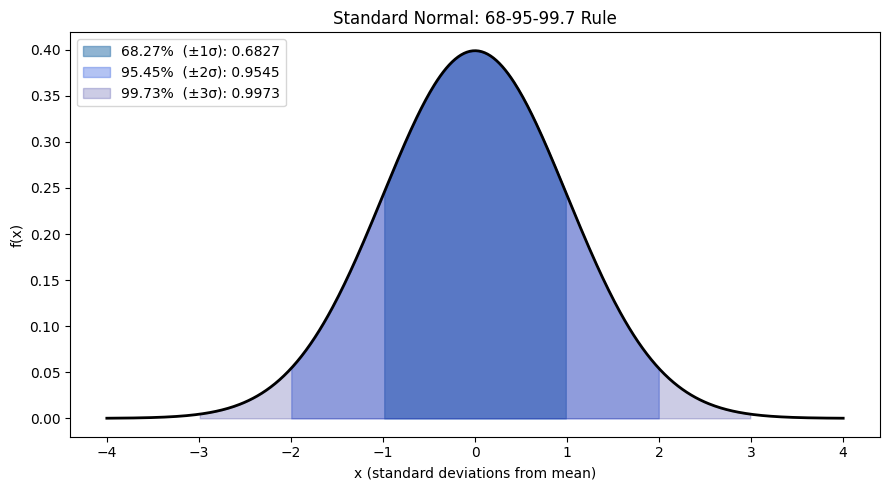

In [3]:
# The 68-95-99.7 rule
rv = stats.norm(0, 1)
x = np.linspace(-4, 4, 500)

fig, ax = plt.subplots(figsize=(9, 5))
pdf_vals = rv.pdf(x)
ax.plot(x, pdf_vals, 'k', linewidth=2)

regions = [
    (1, 'steelblue',  0.6, '68.27%  (±1σ)'),
    (2, 'royalblue',  0.4, '95.45%  (±2σ)'),
    (3, 'navy',       0.2, '99.73%  (±3σ)'),
]
for nsigma, color, alpha, label in regions:
    mask = (x >= -nsigma) & (x <= nsigma)
    p = rv.cdf(nsigma) - rv.cdf(-nsigma)
    ax.fill_between(x, 0, pdf_vals, where=mask, color=color, alpha=alpha, label=f'{label}: {p:.4f}')

ax.set_xlabel('x (standard deviations from mean)')
ax.set_ylabel('f(x)')
ax.set_title('Standard Normal: 68-95-99.7 Rule')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 2. Standardization (Z-Score)

Any N(μ, σ²) variable can be converted to the standard normal N(0,1) via:
$$Z = \frac{X - \mu}{\sigma}$$

This is **standardization** or computing the **z-score**. It tells you how many standard deviations an observation is from the mean.

In [4]:
# Heights: N(170cm, 10^2)
mu_h, sigma_h = 170, 10
rv_h = stats.norm(mu_h, sigma_h)

height = 185  # cm
z = (height - mu_h) / sigma_h

print(f"Height = {height}cm")
print(f"Z = ({height} - {mu_h}) / {sigma_h} = {z:.2f}")
print(f"P(X < {height}) = P(Z < {z:.2f}) = {rv_h.cdf(height):.4f}")
print(f"Being {height}cm puts you in the {rv_h.cdf(height)*100:.1f}th percentile")

# Verify: P(X<185) using standard normal
p_standard = stats.norm.cdf(z)
p_original = rv_h.cdf(height)
print(f"\nSame result via standard normal: {p_standard:.4f}")
print(f"Match: {np.isclose(p_standard, p_original)}")

Height = 185cm
Z = (185 - 170) / 10 = 1.50
P(X < 185) = P(Z < 1.50) = 0.9332
Being 185cm puts you in the 93.3th percentile

Same result via standard normal: 0.9332
Match: True


## 3. The Normal CDF

The normal CDF has no closed-form expression. It is defined in terms of the error function:
$$\Phi(x) = \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$$

Computing this numerically is essential — every statistical test uses it.

In [5]:
from scipy.special import erf

def normal_cdf(x):
    """Standard normal CDF via error function."""
    return 0.5 * (1 + erf(x / np.sqrt(2)))

x_vals = np.array([-3, -2, -1, 0, 1, 2, 3])
print("Standard Normal CDF:")
for x_val in x_vals:
    phi = normal_cdf(x_val)
    scipy_val = stats.norm.cdf(x_val)
    print(f"  Φ({x_val:+.0f}) = {phi:.6f}  scipy={scipy_val:.6f}  match={np.isclose(phi, scipy_val)}")

Standard Normal CDF:
  Φ(-3) = 0.001350  scipy=0.001350  match=True
  Φ(-2) = 0.022750  scipy=0.022750  match=True
  Φ(-1) = 0.158655  scipy=0.158655  match=True
  Φ(+0) = 0.500000  scipy=0.500000  match=True
  Φ(+1) = 0.841345  scipy=0.841345  match=True
  Φ(+2) = 0.977250  scipy=0.977250  match=True
  Φ(+3) = 0.998650  scipy=0.998650  match=True


## 4. Generating Normal Samples: Box-Muller Transform

Given two independent Uniform(0,1) variables U₁ and U₂:
$$Z_1 = \sqrt{-2 \ln U_1} \cos(2\pi U_2)$$
$$Z_2 = \sqrt{-2 \ln U_1} \sin(2\pi U_2)$$

Both Z₁ and Z₂ are independent standard normal samples.

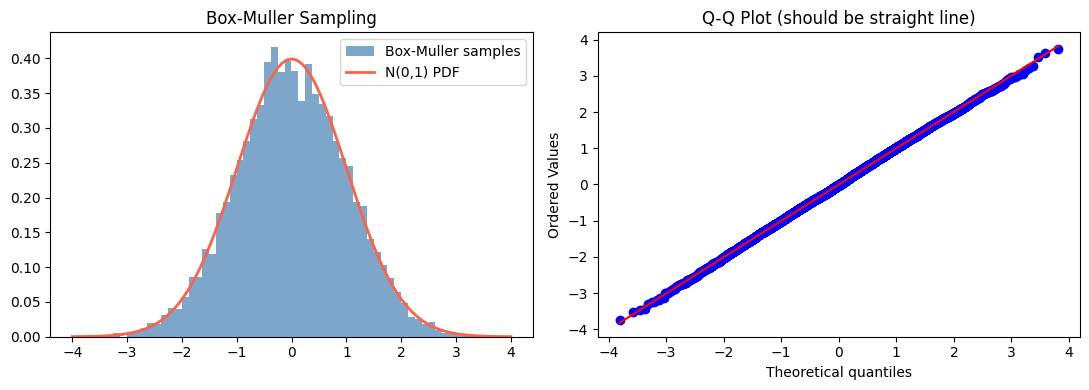

Sample mean: -0.0020  (expected: 0)
Sample std:  1.0032  (expected: 1)


In [6]:
def box_muller(n, seed=None):
    """Generate n standard normal samples via Box-Muller transform."""
    rng = np.random.default_rng(seed)
    n_pairs = (n + 1) // 2
    u1 = rng.uniform(0, 1, n_pairs)
    u2 = rng.uniform(0, 1, n_pairs)
    
    r = np.sqrt(-2 * np.log(u1))
    theta = 2 * np.pi * u2
    
    z1 = r * np.cos(theta)
    z2 = r * np.sin(theta)
    
    return np.concatenate([z1, z2])[:n]

n = 10_000
samples = box_muller(n, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

x_range = np.linspace(-4, 4, 300)
axes[0].hist(samples, bins=60, density=True, color='steelblue', alpha=0.7, label='Box-Muller samples')
axes[0].plot(x_range, stats.norm.pdf(x_range), 'tomato', linewidth=2, label='N(0,1) PDF')
axes[0].set_title('Box-Muller Sampling')
axes[0].legend()

# Q-Q plot against standard normal
stats.probplot(samples, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (should be straight line)')

plt.tight_layout()
plt.show()

print(f"Sample mean: {samples.mean():.4f}  (expected: 0)")
print(f"Sample std:  {samples.std():.4f}  (expected: 1)")

## 5. Normal in Machine Learning

- **Weight initialization**: Glorot/He initialization draws weights from N(0, σ²). *(Connected to Part VI — Linear Algebra for Neural Networks, ch177.)*
- **Noise modeling**: measurement noise is typically assumed Gaussian.
- **Log-likelihood**: maximizing likelihood under Gaussian noise is equivalent to minimizing MSE.
- **Gaussian processes**: a distribution over functions, used in Bayesian optimization.

## 6. Summary

- N(μ, σ²) is parameterized by mean μ and variance σ². The PDF is a bell curve centered at μ with width determined by σ.
- 68-95-99.7% of probability mass lies within 1, 2, 3 standard deviations of the mean.
- Standardization Z = (X−μ)/σ reduces any normal to N(0,1).
- The CDF has no closed form; it is computed via the error function.
- Box-Muller generates normal samples from uniform inputs.

---

## 7. Forward References

The normal distribution is the limit of sums of independent random variables — the content of ch254 (Central Limit Theorem). Its role in inference (confidence intervals, hypothesis tests) is the subject of Part IX. The multivariate normal distribution generalizes to vectors and is defined by a mean vector and covariance matrix *(see ch176 — Projection Matrices and ch174 — Linear Transformations for the matrix connection)*.